DuckDuckGo Search

In [3]:
%pip install -U ddgs



Note: you may need to restart the kernel to use updated packages.


In [4]:
from langchain_community.tools import DuckDuckGoSearchRun

search_tool = DuckDuckGoSearchRun()
results = search_tool.invoke("What is the weather in Islamabad 20 feb 2026")
print(results)

Live wind, rain, radar or temperature maps, more than 50 weather layers, detailed forecast for your place, data from the best weather forecast models. According to the weather forecast for Indian Illegally Occupied Jammu and Kashmir, cold and dry weather is expected in Srinagar, Pulwama, Anantnag, Shopian and Baramula while dry in Jammu and very cold and dry in Leh. Temperature recorded this morning Find current time, weather , sun, moon, and much more...Fri = Friday, 20 February 2026 (91 places). Full weather forecast for Istanbul in March 2026 . Check the temperatures, chance of rain and more in Istanbul during March. Подробный прогноз погоды в Астане на март 2026 года - информация о дневной и ночной температуре, осадках в Астане, Астана, Казахстан - World- Weather .Ru.


In [5]:
from langchain_community.tools import ShellTool
shell_tool = ShellTool()
result = shell_tool.invoke("whoami")
print(result)

Executing command:
 whoami
desktop-1giltns\sikandar



c:\Users\Sikandar\miniconda3\envs\myvenv\lib\site-packages\langchain_community\tools\shell\tool.py:33: UserWarning: The shell tool has no safeguards by default. Use at your own risk.
  warnings.warn(


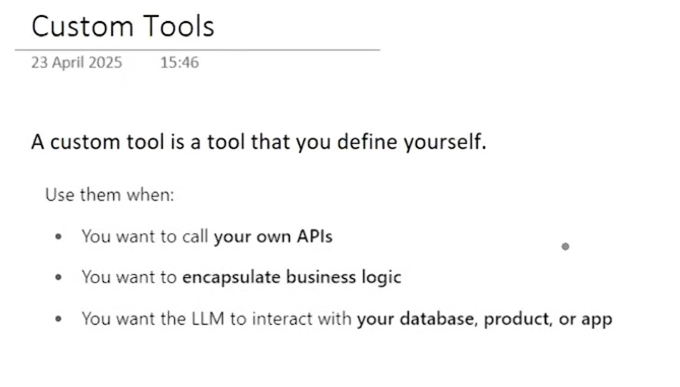

In [7]:
from langchain_core.tools import tool

# step 1: create a function
@tool
def multiply(a: int, b: int) -> int:
    """Multiplies two numbers a and b and returns the result."""
    return a * b

# step 2: use the function
multiply_result = multiply.invoke({"a": 5, "b": 10})

print(multiply_result)


50


In [8]:
print(multiply.name)
print(multiply.description)
print(multiply.args_schema)
print(multiply.args)

multiply
Multiplies two numbers a and b and returns the result.
<class 'langchain_core.utils.pydantic.multiply'>
{'a': {'title': 'A', 'type': 'integer'}, 'b': {'title': 'B', 'type': 'integer'}}


In [9]:
multiply.args_schema.model_json_schema()

{'description': 'Multiplies two numbers a and b and returns the result.',
 'properties': {'a': {'title': 'A', 'type': 'integer'},
  'b': {'title': 'B', 'type': 'integer'}},
 'required': ['a', 'b'],
 'title': 'multiply',
 'type': 'object'}

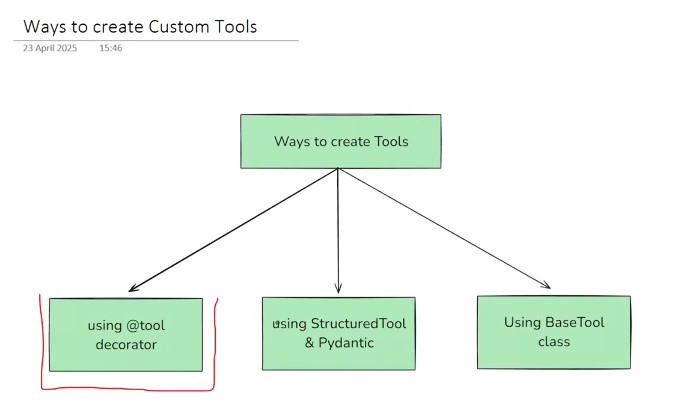
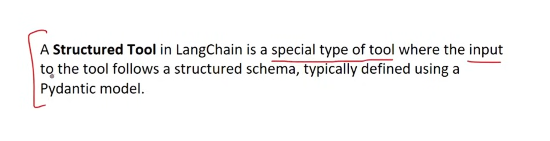
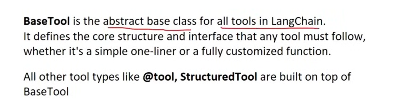

In [13]:
from pydantic import BaseModel, Field
from langchain_core.tools import StructuredTool
class MultiplyArgs(BaseModel):
    a:  int = Field(required=True, description="The first number to multiply")
    b:  int = Field(required=True, description="The second number to multiply")



def multiply(a: int, b: int) -> int:
    """Multiplies two numbers a and b and returns the result."""
    return a * b


multiply_tool = StructuredTool.from_function(
    func=multiply,
    name="MultiplyArgs",
    description="Multiplies two numbers a and b and returns the result.",
    args_schema = MultiplyArgs

)
result = multiply_tool.invoke({"a": 5, "b": 10})
print(result)


50


C:\Users\Sikandar\AppData\Local\Temp\ipykernel_28384\2335820815.py:4: PydanticDeprecatedSince20: Using extra keyword arguments on `Field` is deprecated and will be removed. Use `json_schema_extra` instead. (Extra keys: 'required'). Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.12/migration/
  a:  int = Field(required=True, description="The first number to multiply")
C:\Users\Sikandar\AppData\Local\Temp\ipykernel_28384\2335820815.py:5: PydanticDeprecatedSince20: Using extra keyword arguments on `Field` is deprecated and will be removed. Use `json_schema_extra` instead. (Extra keys: 'required'). Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.12/migration/
  b:  int = Field(required=True, description="The second number to multiply")


In [14]:
print(multiply_tool.name)
print(multiply_tool.description)
print(multiply_tool.args_schema)
print(multiply_tool.args)
print(multiply_tool.args_schema.model_json_schema())

MultiplyArgs
Multiplies two numbers a and b and returns the result.
<class '__main__.MultiplyArgs'>
{'a': {'description': 'The first number to multiply', 'required': True, 'title': 'A', 'type': 'integer'}, 'b': {'description': 'The second number to multiply', 'required': True, 'title': 'B', 'type': 'integer'}}
{'properties': {'a': {'description': 'The first number to multiply', 'required': True, 'title': 'A', 'type': 'integer'}, 'b': {'description': 'The second number to multiply', 'required': True, 'title': 'B', 'type': 'integer'}}, 'required': ['a', 'b'], 'title': 'MultiplyArgs', 'type': 'object'}


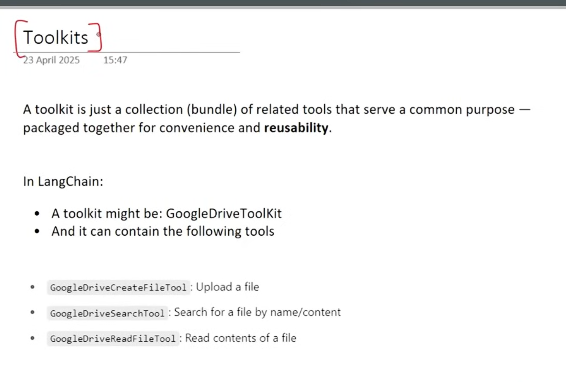

In [15]:
@tool
def add(a: int, b: int) -> int:
    """Adds two numbers a and b and returns the result."""
    return a + b

@tool
def subtract(a: int, b: int) -> int:
    """Subtracts two numbers a and b and returns the result."""
    return a - b
class Mathtoolkit:
    def get_tools(self):
        return [add, subtract]
toolkit = Mathtoolkit()
tools = toolkit.get_tools()
for tool in tools:
    print(tool.name)
    print(tool.description)
    print(tool.args_schema)
    print(tool.args)

add
Adds two numbers a and b and returns the result.
<class 'langchain_core.utils.pydantic.add'>
{'a': {'title': 'A', 'type': 'integer'}, 'b': {'title': 'B', 'type': 'integer'}}
subtract
Subtracts two numbers a and b and returns the result.
<class 'langchain_core.utils.pydantic.subtract'>
{'a': {'title': 'A', 'type': 'integer'}, 'b': {'title': 'B', 'type': 'integer'}}
